# Advanced EDA & Feature Engineering — DecodeLabs Project 1
Cleaning, outlier treatment, and feature engineering on e-commerce order data — ending in a production-ready feature store via Feast.

In [1]:
import numpy as np
import pandas as pd
import statsmodels as sm
import seaborn as sns

## Loading the Data
Reading in the raw order-level dataset before any cleaning begins.

In [2]:
data= pd.read_csv("C:\\Users\\DELL User\\Desktop\\Decodelabs\\Dataset for Data Analytics(CSV).csv")

In [3]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


## Initial Inspection
Shape, dtypes, and missing values first — descriptive stats before any decisions get made.

In [4]:
data.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [6]:
data.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

**Reading the gaps:** Only `CouponCode` has missing data — 309 of 1200 rows (25.75%). Every other column is complete, so this isn't a data quality problem, it's a single categorical field to resolve.

In [7]:
# Missing percentage for all columns
(data.isnull().sum() / len(data)) * 100

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

Handling Missing Data

In [8]:
## UNIQUE COUPON CODES

print(data['CouponCode'].unique())

['SAVE10' 'FREESHIP' nan 'WINTER15']


In [9]:
data['CouponCode'].describe()


count          891
unique           3
top       FREESHIP
freq           313
Name: CouponCode, dtype: object

In [10]:
data['CouponCode'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1200 entries, 0 to 1199
Series name: CouponCode
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 9.5+ KB


In [11]:
## APPLYING LOGIC STRUCTURE THRESHOLD to missing data.
#The missing values are not random. 
#A customer either has a coupon or doesn't
#NaN literally means no coupon was used
# Hence filling the missing data with "NO COUPON USED" is the best way to deal with this variable.
data['CouponCode'] = data['CouponCode'].fillna('NO_COUPON')
print(data['CouponCode'].isnull().sum())

0


In [12]:
#CODE FOR IMPUTING WITH MEAN
# .fillna(mean_value) 
#calculate mean from observed values only
#mean_value = data['Variable'].mean()
#data['Variable'] = data['Variable'].fillna(mean_value)

#CODE FOR IMPUTING WITH MEDIAN
# median_value=data['Variable'].median()
#data['Variable'] = data['Variable'].fillna(median_value)

#USING KNN This is ALSO called Multivariate Imputation — using the joint distribution of all variables to estimate the missing one.


In [14]:
print(data['CouponCode'].isnull().sum())   # Must print 0
print(data['CouponCode'].value_counts())   # 3 codes, total = 1200

0
CouponCode
FREESHIP     313
NO_COUPON    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


**Confirming the fix:** The 309 missing values now sit under `NO_COUPON`, alongside `FREESHIP` (313), `WINTER15` (292), and `SAVE10` (286) — a near-even 4-way split. The "missing" values weren't random; they were customers who simply didn't use a code.

## Detecting Outliers: IQR Method
Using the interquartile range as a distribution-free way to flag extreme values, cross-checked later against Z-scores.

In [15]:
# IQR = Q3 - Q1
# Lower Bound = Q1 - 1.5 * IQR
# Upper Bound = Q3 + 1.5 * IQR
#Anything outside these bounds = OUTLIER

In [16]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO_COUPON,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [17]:
## we pplot box pots for a 4 features to identify our outliers
import matplotlib.pyplot as plt
import seaborn as sns

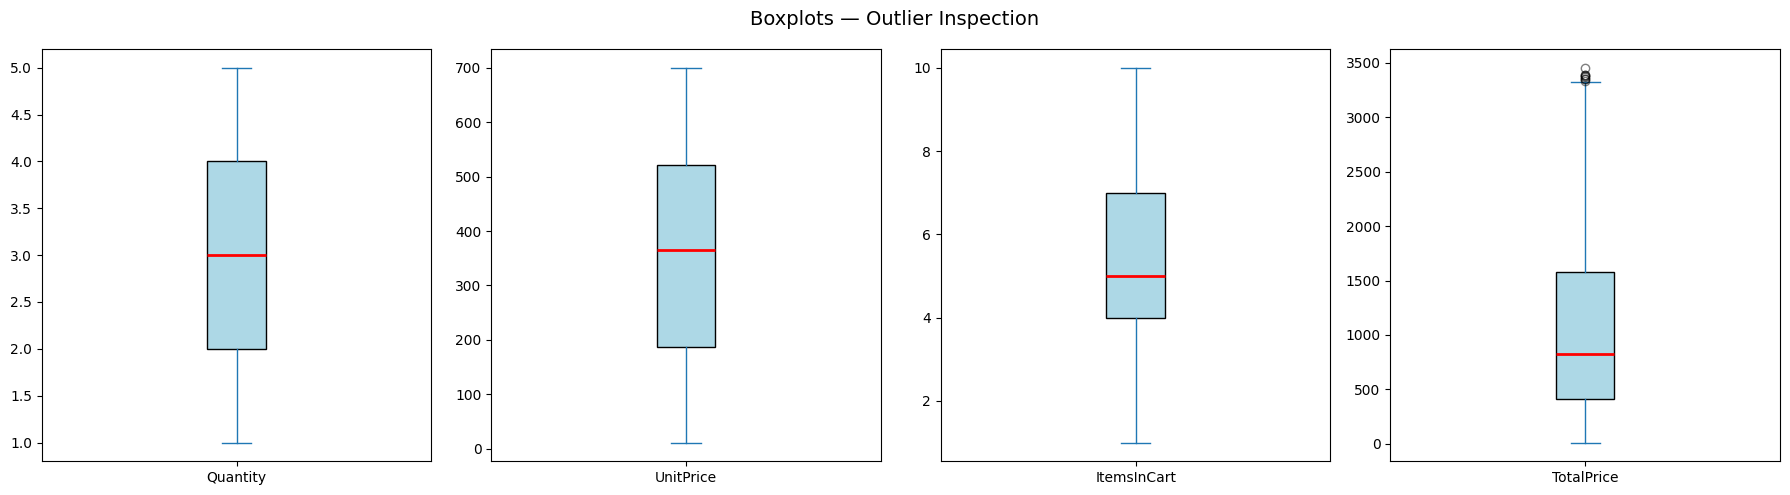

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

data[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].plot(
    kind='box',
    subplots=True,
    ax=axes,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='red', alpha=0.5)  # outliers shown as red dots
)

plt.suptitle("Boxplots — Outlier Inspection", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
data['TotalPrice'].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

In [20]:
Q1  =  410.52  ## 25% value
Q3  = 1578.47 ## 75% value
IQR= Q3-Q1

print('IQR IS', Q3-Q1)


IQR IS 1167.95


In [21]:
LowerBound =  Q1 - (1.5 * IQR)
UpperBound = Q3 + (1.5 * IQR)
print("LowerBound = ", Q1 - (1.5 * IQR))
          
print("UpperBound =", Q3 + (1.5 * IQR))
       
# Any TotalPrice above 3330.40 is an outlier
# Looking at the max = 3456.40 — that's above our upper bound=  3330.3950000000004.. hence outlier detection
# No outliers on the low end since lower bound is negative
# Your mean (1053.97) is higher than your median (823.61) — this confirms right skew, meaning a few high-value orders are pulling the mean up


LowerBound =  -1341.4050000000002
UpperBound = 3330.3950000000004


**Setting the fence:** IQR = 1167.95, giving an upper bound of 3330.40 on `TotalPrice`. The lower bound (-1341.41) is negative and meaningless here since price can't go below zero — only the upper bound matters for this variable.

In [22]:
 # Counting outliers before capping
outliers= data[(data['TotalPrice']<LowerBound)|(data['TotalPrice']>UpperBound )]
outliers
#     outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO_COUPON,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO_COUPON,Facebook,3390.95


In [23]:
##number of outliers
#len(outliers)
outliers.shape[0]
print('number of outlier are',outliers.shape[0])


number of outlier are 8


**Result:** 8 orders (0.67% of the data) sit above the IQR upper bound — a small, manageable set of extreme values, not a systemic issue.

In [24]:
#Using the Z- score detection method
#Z = (X - mean) / std , X= 3*std + mean
# Calculate the Zscore upper and lower boundary using 3 is the threshold Z score
mean = 1053.97
std  =  819.86
UpperBound_Zscore = 3*std + mean
print('Upper Bound value using Z score is',UpperBound_Zscore)

## thi value of 3513.55 is higher than the upper bound value using IQR, hence not a good meathod of detecting outliers given when the distribution is skewed.
               

Upper Bound value using Z score is 3513.55


In [25]:
Outliers_Zscore=data[(data['TotalPrice']>UpperBound_Zscore)]
Outliers_Zscore ## this catches zero outliers. Confirming the IQR methond is a robust non aparametric way of detecting outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


**Cross-checking:** The Z-score method (threshold = 3σ, upper bound 3513.55) flags zero outliers — stricter than IQR. This gap is expected: Z-score assumes normality, IQR doesn't. Since `TotalPrice` is right-skewed, IQR is the more trustworthy method here.

## Treating Outliers
Comparing deletion vs. winsorization. capping extreme values beats losing rows.

In [26]:
# DELETION METHOD

data_delete=data[data['TotalPrice']< UpperBound] 
data_delete
#data_delete.shape[0]
print("Rows remaining:", data_delete.shape[0])
## reduced rows. Not recommended. it sacrifices adjacent data values
# Before = 1200 rows
# After  = 1192 rows
# Lost   =    8 rows

Rows remaining: 1192


In [27]:
## WINSORIZATION METHOD. WE CLIP VALUES #any value above 3330.40 gets replaced with 3330.40 exactly. No rows lost, just the extreme values capped.
data['TotalPrice']=np.clip(data['TotalPrice'],LowerBound, UpperBound)
data.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.643100
std,1.407557,197.177146,2.281983,818.937626
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3330.395000


**Effect of capping:** Mean `TotalPrice` barely moves (1053.97 → 1053.64) and std tightens slightly (819.86 → 818.94). Capping neutralized the 8 extreme values without distorting the overall distribution.Also the max of totalPrice becomes 3330.40

## Exploratory Data Analysis
Visualizing distributions post-cleaning to sanity-check the outlier treatment before engineering new features.

array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
      dtype=object)

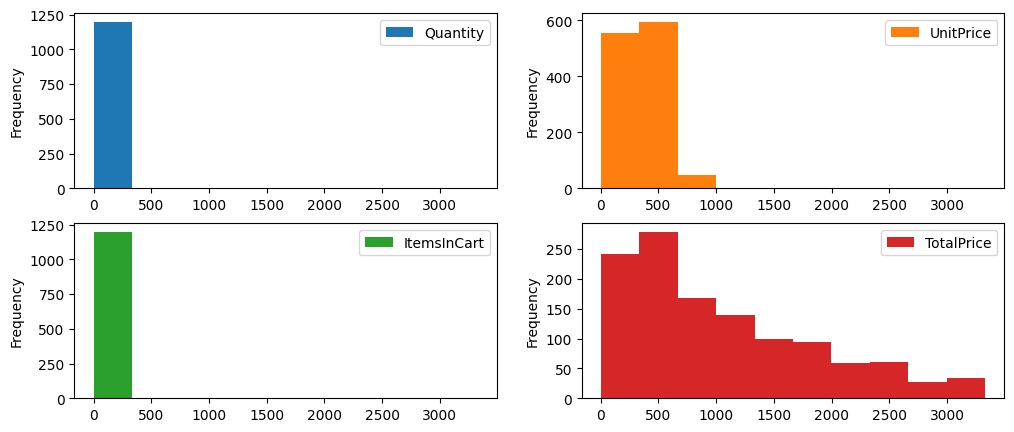

In [28]:
fig, axes= plt.subplots(2,2, figsize=(12,5))

data[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].plot(kind= 'hist',subplots=True, ax=axes)

FEATURE ENGINEERING
1. Date features →  Months, and days of the week
2. otherItemsInCart    → ItemsInCart - Quantity
3. Is_Digital_Channel  → from ReferralSource

In [29]:
# Discount_Indicator → did customer use a coupon?

# True = used a coupon    (SAVE10, FREESHIP, WINTER15)
# False = no coupon used   (NO_COUPON)

#data['DiscountIndicator'] = (data['CouponCode'] != 'NO_COUPON').astype('bool')

In [30]:
# Order_Completed → did order succeed?

# True = Delivered
# False = Cancelled, Pending, Processing, Returned
#data['OrderCompleted'] = (data['OrderStatus'] =='Delivered').astype('bool')

In [31]:
# Is_Digital_Channel → online vs offline referral?

# Yes = Social Media, Email, Online Ad
# No = Word of Mouth, Direct

#data['DigitalRefferals']=(data['ReferralSource']=='Referral').astype('bool')

In [32]:
# Never engineer features blindly
# ↓
# Always verify they carry signal toward your target
# ↓
# Weak features add noise not predictive power!

In [33]:
# Date is extracted into Month, Quarter and DayOfWeek because raw dates carry no mathematical signal.
# Extracted features capture cyclical buying patterns e.g. December = high sales, Q4 = holiday season
# enabling the model to learn temporal behavior

### First parsing the date column
data['Date']=pd.to_datetime(data['Date'])

In [34]:
## Extracting the date features.. Months, quater, and days of the week
# month number January   = 1...December  = 12
# quarter: Jan-Mar = 1,Apr-Jun = 2,Jul-Sep = 3, Oct-Dec = 4
# Day of the week: Monday  = 0Sunday  = 6

data['Month']=data['Date'].dt.month
#data['Quater']=data['Date'].dt.quarter
data['DayOfWeek']=data['Date'].dt.day_of_week

In [35]:
# Checking the correlation against the target

date_Corr= data[['Month', 'DayOfWeek','TotalPrice']].corr().abs()['TotalPrice']
date_Corr
#All three date features show very low correlation with TotalPrice
#Date features do NOT affect TotalPrice the dataset!
# ↓
# Engineering them adds NOISE
# not predictive power
# ↓
# Drop them!


Month         0.027848
DayOfWeek     0.007422
TotalPrice    1.000000
Name: TotalPrice, dtype: float64

In [36]:
data['otherItemsInCart']=(data['ItemsInCart']-data['Quantity'])
data['Price_Per_Cart_Item'] = data['TotalPrice'] / data['ItemsInCart']

# data['Cart_Filling_Rate'] = data['Quantity'] / data['ItemsInCart']
#data['PotentialCartValue']= data['ItemsInCart']*data['UnitPrice']

In [37]:
Other_corr=data[['otherItemsInCart','Price_Per_Cart_Item','TotalPrice']].corr().abs()['TotalPrice']
Other_corr

otherItemsInCart       0.017112
Price_Per_Cart_Item    0.696036
TotalPrice             1.000000
Name: TotalPrice, dtype: float64

## Phase Two: Categorical Variables
Auditing categorical columns by cardinality. High-cardinality fields get dropped before encoding to avoid distorting the model.

In [38]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,DayOfWeek,otherItemsInCart,Price_Per_Cart_Item
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,2,2,407.585714
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,4,1,100.900000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,1,3,344.175000
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,6,4,54.638000
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,3,4,313.005000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,6,3,5,17.840000
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO_COUPON,Facebook,1325.06,3,0,3,265.012000
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,7,3,0,436.840000
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,8,3,0,262.520000


In [39]:
## First consider all categorical variable 
# then consider their counts 
# drop variables with high extreme levels as they can distort the data and destroy model performance

cat_vars1 = ['CustomerID','Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus','TrackingNumber', 'ReferralSource', 'CouponCode']
data[cat_vars1].nunique()



CustomerID         1189
Product               7
ShippingAddress     655
PaymentMethod         5
OrderStatus           5
TrackingNumber     1200
ReferralSource        5
CouponCode            4
dtype: int64

In [40]:
data.value_counts()

OrderID    Date        CustomerID  Product  Quantity  UnitPrice  ShippingAddress  PaymentMethod  OrderStatus  TrackingNumber  ItemsInCart  CouponCode  ReferralSource  TotalPrice  Month  DayOfWeek  otherItemsInCart  Price_Per_Cart_Item
ORD201183  2023-04-05  C12607      Desk     1         281.52     460 Main St      Gift Card      Shipped      TRK83653396     6            WINTER15    Referral        281.52      4      2          5                 46.920000              1
ORD201182  2025-06-14  C18473      Chair    2         420.29     700 Main St      Gift Card      Returned     TRK97834202     3            SAVE10      Google          840.58      6      5          1                 280.193333             1
ORD201181  2023-07-27  C70246      Desk     3         158.74     293 Main St      Online         Pending      TRK45708320     7            FREESHIP    Instagram       476.22      7      3          4                 68.031429              1
ORD201180  2023-10-31  C42235      Chair    4

## Encoding Categorical Data
One-hot encoding selected categorical variables, dropping the first category per column to avoid the dummy trap.

In [41]:
## Dropping Customer ID,OrderID, Shipping Address, and tracking number
cat_vars = ['Product',  'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']
data[cat_vars].nunique()


Product           7
PaymentMethod     5
OrderStatus       5
ReferralSource    5
CouponCode        4
dtype: int64

In [42]:
## we encode chosen categorical variables ie. col_vars in the clean_data.
#  Transforming categorical data into dummy variables,  
# using pd.getdummies() tocreates binary columns per category
#drop_first=True   → drops one category per column
data_encoded = pd.get_dummies(data, columns=cat_vars,drop_first=True)
print(data_encoded)

        OrderID       Date CustomerID  Quantity  UnitPrice ShippingAddress  \
0     ORD200000 2023-01-04     C72649         5     570.62     928 Main St   
1     ORD200001 2024-08-23     C75739         2     151.35     823 Main St   
2     ORD200002 2024-02-27     C81728         5     550.68     512 Main St   
3     ORD200003 2023-10-15     C33540         1     273.19     275 Main St   
4     ORD200004 2025-05-08     C81840         4     626.01     668 Main St   
...         ...        ...        ...       ...        ...             ...   
1195  ORD201195 2024-06-20     C21126         1     107.04     392 Main St   
1196  ORD201196 2024-03-04     C20095         2     662.53     778 Main St   
1197  ORD201197 2023-07-13     C79674         2     436.84     275 Main St   
1198  ORD201198 2024-08-22     C64753         4     262.52     509 Main St   
1199  ORD201199 2023-06-11     C57502         4     560.58     201 Main St   

     TrackingNumber  ItemsInCart  TotalPrice  Month  ...  Order

In [43]:
data_encoded.value_counts()

OrderID    Date        CustomerID  Quantity  UnitPrice  ShippingAddress  TrackingNumber  ItemsInCart  TotalPrice  Month  DayOfWeek  otherItemsInCart  Price_Per_Cart_Item  Product_Desk  Product_Laptop  Product_Monitor  Product_Phone  Product_Printer  Product_Tablet  PaymentMethod_Credit Card  PaymentMethod_Debit Card  PaymentMethod_Gift Card  PaymentMethod_Online  OrderStatus_Delivered  OrderStatus_Pending  OrderStatus_Returned  OrderStatus_Shipped  ReferralSource_Facebook  ReferralSource_Google  ReferralSource_Instagram  ReferralSource_Referral  CouponCode_NO_COUPON  CouponCode_SAVE10  CouponCode_WINTER15
ORD201183  2023-04-05  C12607      1         281.52     460 Main St      TRK83653396     6            281.52      4      2          5                 46.920000            True          False           False            False          False            False           False                      False                     True                     False                 False                

## Multicollinearity Check
Correlation matrix on all numeric + encoded columns to confirm engineered features don't duplicate existing signal.

In [44]:
###  DROPPING THESE FROM THE DATA SET
cols_to_drop = ['ShippingAddress', 'OrderID', 'CustomerID', 'TrackingNumber']



print(f"Remaining Columns: {data.shape[1]}")
print(data.columns.tolist())

Remaining Columns: 18
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Month', 'DayOfWeek', 'otherItemsInCart', 'Price_Per_Cart_Item']


In [45]:
### ERADICATING MULTICOLINEARITY 
# build correlation matrix on numeric columns only using .cor()
#.abs()   → takes absolute value so we catch both positive and negative correlations
Corr_data=data_encoded.drop(columns=cols_to_drop)
corr_matrix = Corr_data.corr().abs()

corr_matrix


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,Month,DayOfWeek,otherItemsInCart,Price_Per_Cart_Item,Product_Desk,...,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,CouponCode_NO_COUPON,CouponCode_SAVE10,CouponCode_WINTER15
Date,1.000000,0.039554,0.010876,0.060166,0.046305,0.105521,0.014992,0.047026,0.016383,0.034438,...,0.067151,0.003601,0.011645,0.009925,0.004739,0.015634,0.017362,0.016133,0.027905,0.047270
Quantity,0.039554,1.000000,0.014553,0.650061,0.615362,0.015118,0.018043,0.043713,0.216031,0.012244,...,0.038440,0.066832,0.018314,0.003548,0.005994,0.010120,0.035045,0.041636,0.002074,0.033381
UnitPrice,0.010876,0.014553,1.000000,0.000602,0.717232,0.026130,0.003633,0.011010,0.748812,0.055251,...,0.002048,0.008485,0.018497,0.036862,0.026991,0.005048,0.033436,0.036048,0.001401,0.004009
ItemsInCart,0.060166,0.650061,0.000602,1.000000,0.392579,0.018151,0.017423,0.787571,0.243178,0.016291,...,0.009227,0.025115,0.000898,0.032203,0.019255,0.003894,0.018507,0.019329,0.006611,0.025219
TotalPrice,0.046305,0.615362,0.717232,0.392579,1.000000,0.027848,0.007422,0.017112,0.696036,0.034038,...,0.016914,0.042942,0.003771,0.025905,0.008961,0.005861,0.018606,0.007658,0.007901,0.012433
Month,0.105521,0.015118,0.026130,0.018151,0.027848,1.000000,0.030858,0.011604,0.005704,0.005826,...,0.003873,0.017119,0.037172,0.025507,0.006095,0.000179,0.078895,0.019073,0.034187,0.014257
DayOfWeek,0.014992,0.018043,0.003633,0.017423,0.007422,0.030858,1.000000,0.008274,0.010318,0.005477,...,0.006250,0.041161,0.020681,0.039238,0.032609,0.040173,0.002421,0.014781,0.009138,0.019987
otherItemsInCart,0.047026,0.043713,0.011010,0.787571,0.017112,0.011604,0.008274,1.000000,0.494904,0.011490,...,0.019041,0.021177,0.013672,0.045215,0.020455,0.003087,0.004088,0.008351,0.010373,0.006086
Price_Per_Cart_Item,0.016383,0.216031,0.748812,0.243178,0.696036,0.005704,0.010318,0.494904,1.000000,0.043106,...,0.001163,0.025485,0.013208,0.047955,0.023421,0.009491,0.012654,0.004140,0.012610,0.002124
Product_Desk,0.034438,0.012244,0.055251,0.016291,0.034038,0.005826,0.005477,0.011490,0.043106,1.000000,...,0.026562,0.017683,0.001756,0.001828,0.028981,0.025027,0.015079,0.015166,0.030943,0.042513


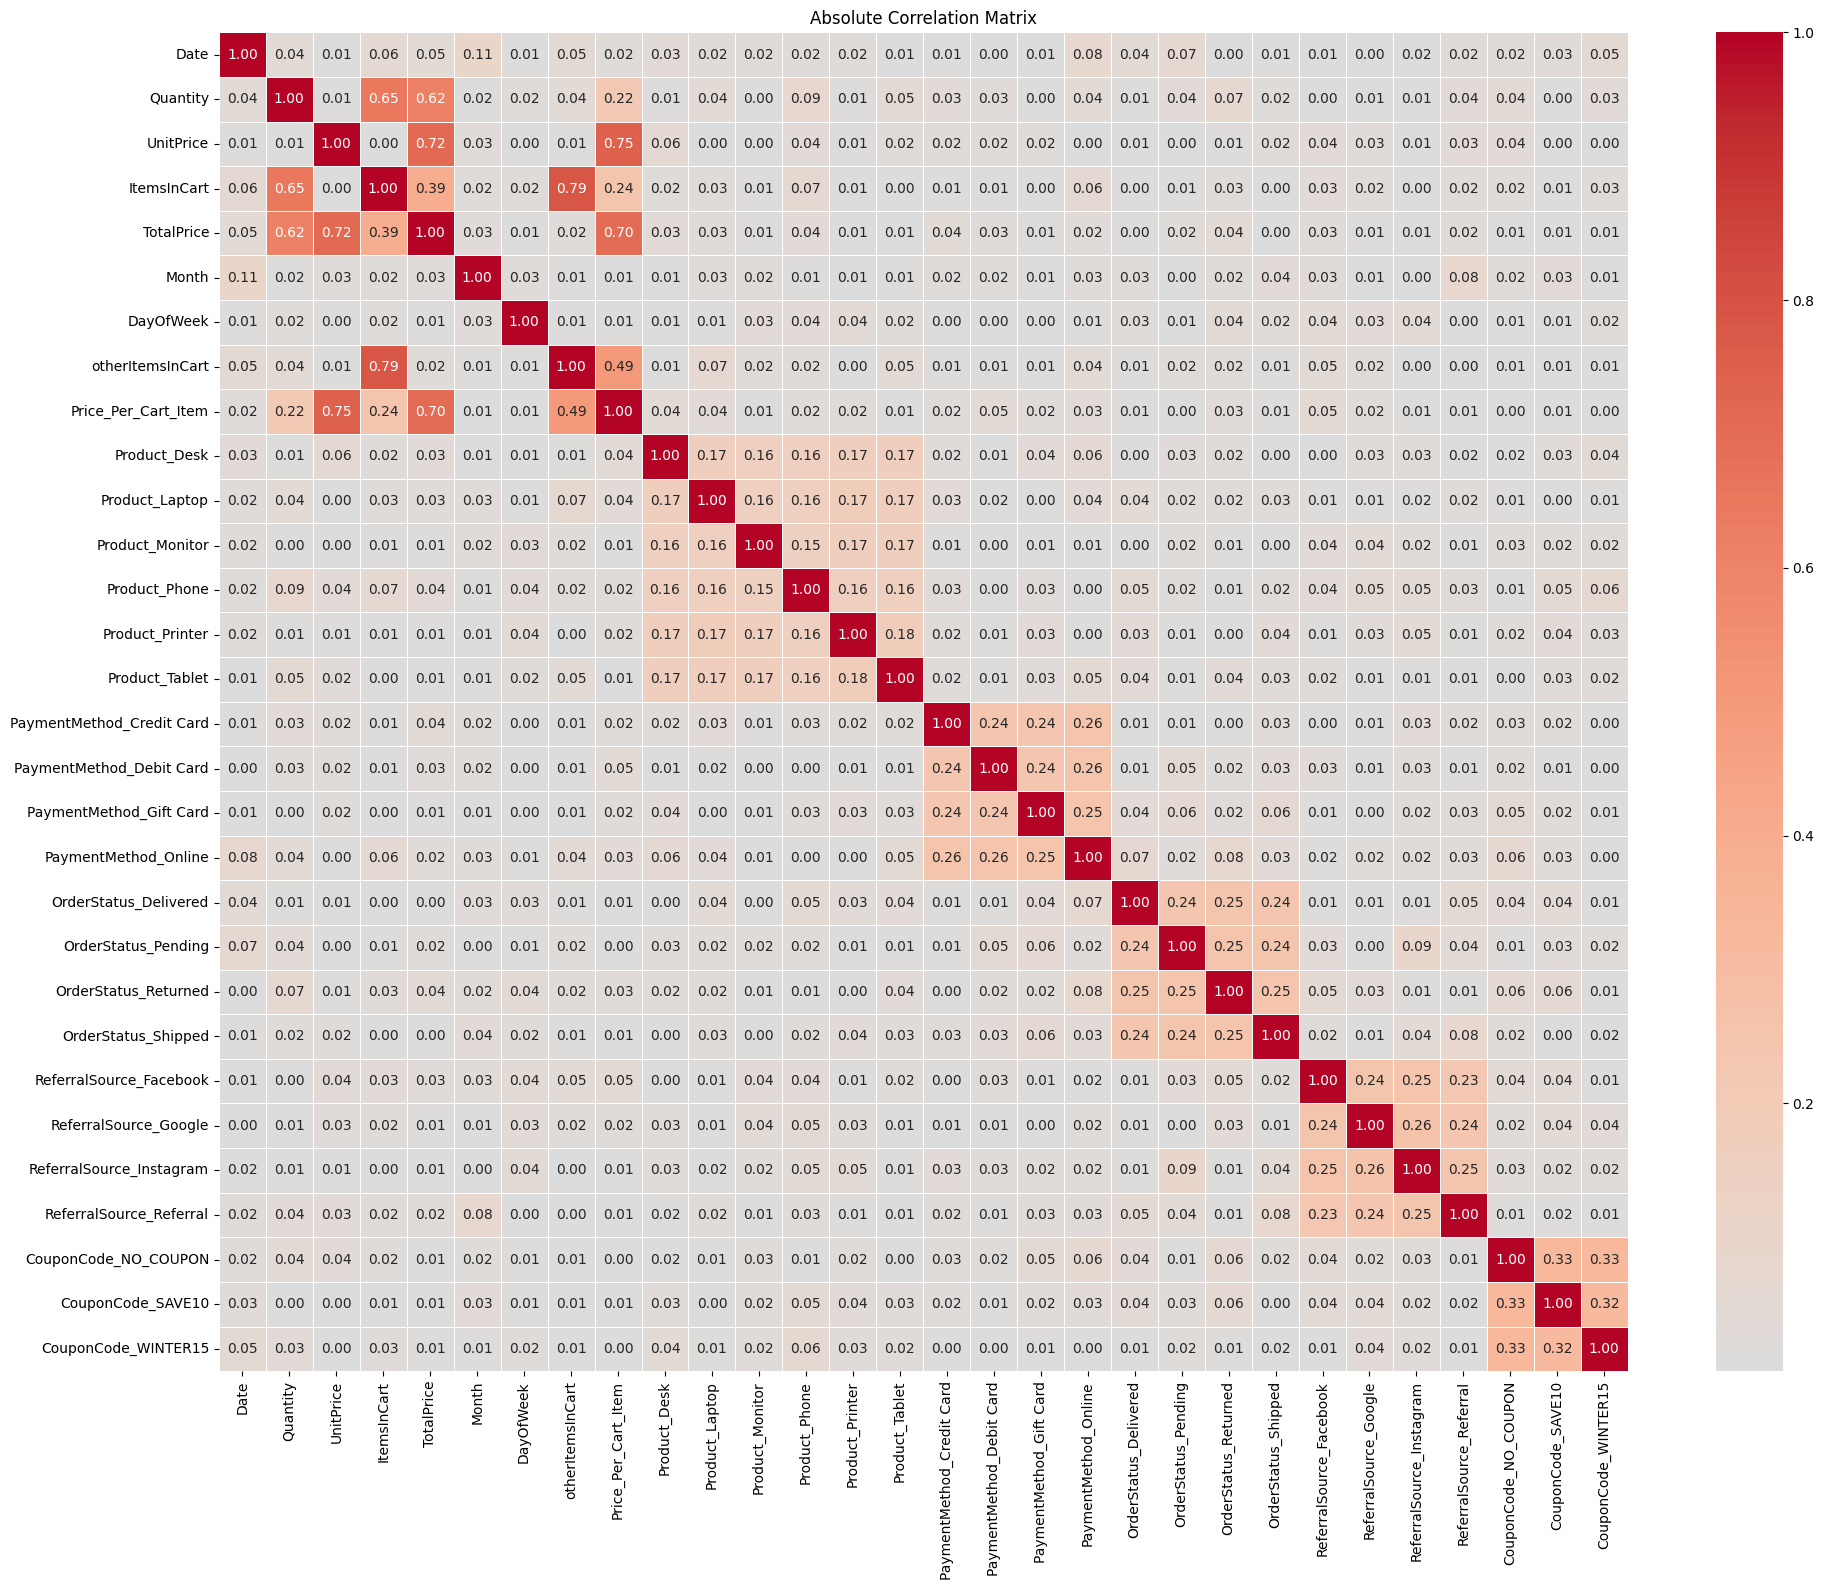

In [46]:
###USING THE HEAT MAP MATRIX
# corr_matrix  → the data we're visualizing
# annot=True   → print the actual correlation 
#                number inside each cell
# fmt='.2f'    → round to 2 decimal places
#                e.g. 0.8234 → 0.82
# cmap='coolwarm' → color scheme:
#                RED   = high correlation (problem!)
#                BLUE  = low correlation (safe!)
# center=0     → makes 0 correlation appear 
#                as neutral white
# linewidths=0.5 → thin lines between cells
#                  for readability

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title("Absolute Correlation Matrix")
plt.tight_layout()
plt.show()


In [47]:
print('No multicollinearity detected')
print('All 30 columns are statistically independent')
print('These columns ->( ShippingAddress', 'OrderID', 'CustomerID', 'TrackingNumber) need to be dropped! from the main data set')

No multicollinearity detected
All 30 columns are statistically independent
These columns ->( ShippingAddress OrderID CustomerID TrackingNumber) need to be dropped! from the main data set


In [48]:
# isolate numeric columns only
numeric_data = Corr_data.select_dtypes(include=['int64', 'float64', 'bool'])

# correlations against TotalPrice
target_corr = numeric_data.corr().abs()['TotalPrice'].sort_values(ascending=False)

print(target_corr)

TotalPrice                   1.000000
UnitPrice                    0.717232
Price_Per_Cart_Item          0.696036
Quantity                     0.615362
ItemsInCart                  0.392579
PaymentMethod_Credit Card    0.044438
OrderStatus_Returned         0.042942
Product_Phone                0.038280
Product_Desk                 0.034038
PaymentMethod_Debit Card     0.031159
Product_Laptop               0.028297
ReferralSource_Facebook      0.025905
PaymentMethod_Online         0.023846
ReferralSource_Referral      0.018606
otherItemsInCart             0.017112
OrderStatus_Pending          0.016914
Product_Printer              0.013870
CouponCode_WINTER15          0.012433
Product_Monitor              0.011431
PaymentMethod_Gift Card      0.010036
ReferralSource_Google        0.008961
CouponCode_SAVE10            0.007901
CouponCode_NO_COUPON         0.007658
Product_Tablet               0.006284
ReferralSource_Instagram     0.005861
OrderStatus_Shipped          0.003771
OrderStatus_

In [49]:
Corr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       1200 non-null   datetime64[ns]
 1   Quantity                   1200 non-null   int64         
 2   UnitPrice                  1200 non-null   float64       
 3   ItemsInCart                1200 non-null   int64         
 4   TotalPrice                 1200 non-null   float64       
 5   Month                      1200 non-null   int32         
 6   DayOfWeek                  1200 non-null   int32         
 7   otherItemsInCart           1200 non-null   int64         
 8   Price_Per_Cart_Item        1200 non-null   float64       
 9   Product_Desk               1200 non-null   bool          
 10  Product_Laptop             1200 non-null   bool          
 11  Product_Monitor            1200 non-null   bool          
 12  Produc

## Data Contracts with Pandera
Defining schema rules as a hypothesis test — H0: data meets the contract. Enforced before anything goes downstream.

In [50]:
#pip install pandera

In [51]:
Corr_data.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,Month,DayOfWeek,otherItemsInCart,Price_Per_Cart_Item
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.643100,5.995000,3.050833,2.539167,207.677415
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,1.000000,0.000000,0.000000,1.898333
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,3.000000,1.000000,1.000000,83.053214
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,6.000000,3.000000,3.000000,172.681250
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,9.000000,5.000000,4.000000,301.199667
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3330.395000,12.000000,6.000000,5.000000,697.930000
std,NaN,1.407557,197.177146,2.281983,818.937626,3.344293,2.026081,1.735697,154.143910


In [52]:
Corr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       1200 non-null   datetime64[ns]
 1   Quantity                   1200 non-null   int64         
 2   UnitPrice                  1200 non-null   float64       
 3   ItemsInCart                1200 non-null   int64         
 4   TotalPrice                 1200 non-null   float64       
 5   Month                      1200 non-null   int32         
 6   DayOfWeek                  1200 non-null   int32         
 7   otherItemsInCart           1200 non-null   int64         
 8   Price_Per_Cart_Item        1200 non-null   float64       
 9   Product_Desk               1200 non-null   bool          
 10  Product_Laptop             1200 non-null   bool          
 11  Product_Monitor            1200 non-null   bool          
 12  Produc

In [53]:
# fix data types to match schema
Corr_data['Month']            = Corr_data['Month'].astype('int64')
Corr_data['DayOfWeek']        = Corr_data['DayOfWeek'].astype('int64')
Corr_data['otherItemsInCart'] = Corr_data['otherItemsInCart'].astype('float64')

# verify
print(Corr_data[['Month', 'DayOfWeek', 'otherItemsInCart']].dtypes)

Month                 int64
DayOfWeek             int64
otherItemsInCart    float64
dtype: object


In [54]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check


# pa               → the main pandera library

# Column           → defines rules for 
#                    a single column

# DataFrameSchema  → combines all column 
#                    rules into one contract

# Check            → the actual statistical 
#                    rule being enforced
#                    e.g. value must be > 0


# DataFrameSchema  → the full contract
# Column           → one clause in the contract
# Check            → the condition of that clause



In [55]:
import pandera.pandas as pa
from pandera.pandas import Column, DataFrameSchema, Check

In [56]:



#Why TotalPrice Has Two Checks
# Check.greater_than(0),          # lower boundary
# Check.less_than_or_equal_to(3330.40)  # upper boundary
#                                       # our IQR bound!

Schema = DataFrameSchema({
    'Quantity'           : Column(int, Check.greater_than(0)),
    'UnitPrice'          : Column(float, Check.greater_than(0)),
    'ItemsInCart'        : Column(int, Check.greater_than(0)),
    'Month'              : Column(int, Check.greater_than(0)),
    'DayOfWeek'          : Column(int, Check.greater_than_or_equal_to(0)),
    'otherItemsInCart'   : Column(float, Check.greater_than_or_equal_to(0)),
    'Price_Per_Cart_Item': Column(float, Check.greater_than(0)),
    'TotalPrice'         : Column(float, [
                               Check.greater_than(0),
                               Check.less_than_or_equal_to(3330.40)
                           ])
})

In [ ]:
# Assume try/except as HYPOTHESIS TEST:

# H0 (null)       → data meets all contracts
# H1 (alternative)→ data violates contracts

# Yes! = fail to reject H0 → data is clean
# No! = reject H0  → violations exist

try:
    Schema.validate(Corr_data,lazy=True)
    print(' YES!All validations passed! Data is clean')
    print('Data meets all statistical contracts')
except pa.errors.SchemaErrors as err:
    print(' NO! Schema violations found')   
    print( err.failure_cases)

 YES!All validations passed! Data is clean
Data meets all statistical contracts


**Hypothesis test result:** Fail to reject H0 — all Pandera contract checks passed. Data is statistically clean and safe to hand off downstream.

## Feature Store with Feast
Solving training-serving skew by giving training and production a single, shared source of features.

In [58]:
# FEAST FEATURE STORE SETUP
# Feast solves the Training-Serving Skew problem
# by acting as a centralized feature repository.
# Both model training and production predictions
# pull identical features from the same store,
# guaranteeing mathematical consistency
# and eliminating feature computation discrepancies.

# Offline Store → historical features for model training
# Online Store  → current features for real-time predictions

In [59]:
#pip install feast

In [60]:
## restrucuring data
# extract OrderID from original data
# and insert as first column in corr_data
Corr_data.insert(0, 'OrderID', data['OrderID'].values)

Step 1 → Save your cleaned data as parquet
Step 2 → Define your features in Feast
Step 3 → Store them
Step 4 → Retrieve them


In [61]:
import os
from feast import Entity, FeatureView, FileSource, Field, FeatureStore
from feast.types import Float64, Int64
from datetime import timedelta

# Entity      → your observation ID.  defines the unique identifier
# Feature     → your variable. defines one single feature column
# FeatureView → your variable matrix. groups features together into one logical unit
# FileSource  → your data source.tells Feast where raw data lives

In [62]:


# ── Step 1: Create Folder Structure ─────────────────────────
os.makedirs('decodelabs_feature_store/data', exist_ok=True)



In [63]:
# ── Step 2: Save Data as Parquet ─────────────────────────────
Corr_data.to_parquet('decodelabs_feature_store/data/order_features.parquet')


In [64]:
# ── Step 3: Create feature_store.yaml ────────────────────────
config = """project: decodelabs_feature_store
registry: data/registry.db
provider: local
online_store:
    type: sqlite
    path: data/online_store.db
"""
with open('decodelabs_feature_store/feature_store.yaml', 'w') as f:
    f.write(config)

# project    → name of your feature store like naming a database
# registry   → where Feast stores the definitions of your features data/registry.db
# provider   → where everything runs local = your laptop (production = cloud)
# online_store → fast access database type: sqlite = lightweight path: where to save it
#open() → opens a file for writing creates it if it doesn't exist
# 'w' → write mode overwrites if file exists
# f.write() → writes our config string into the file
# with → automatically closes the file when done (safe file handling)



In [65]:

# ── Step 4: Define Data Source ───────────────────────────────
order_source = FileSource(
    path="data/order_features.parquet",
    timestamp_field="Date"
)



In [66]:
# ── Step 5: Define Entity ────────────────────────────────────
order = Entity(
    name="OrderID",
    description="Unique order identifier"
)



C:\Users\DELL User\AppData\Local\Temp\ipykernel_13688\2356411271.py:2: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'OrderID'.
  order = Entity(


In [67]:
# ── Step 6: Define Feature View ──────────────────────────────
order_features = FeatureView(
    name="order_features",
    entities=[order],
    ttl=timedelta(days=365),
    schema=[
        Field(name="Price_Per_Cart_Item", dtype=Float64),
        Field(name="otherItemsInCart",    dtype=Float64),
        Field(name="Month",               dtype=Int64),
        Field(name="DayOfWeek",           dtype=Int64),
    ],
    source=order_source
)



In [68]:
# ── Step 7: Initialize & Apply Feature Store ─────────────────
store = FeatureStore(repo_path="decodelabs_feature_store")
store.apply([order, order_features])

print("✅ Feature store applied successfully!")
print(f"Features stored: {[f.name for f in order_features.schema]}")

✅ Feature store applied successfully!
Features stored: ['Month', 'OrderID', 'Price_Per_Cart_Item', 'otherItemsInCart', 'DayOfWeek']


## Summary
Raw order data cleaned, outliers treated, features engineered and validated against multicollinearity, then served through a Feast feature store — ready for modeling downstream.